PREGUNTAS A RESPONDER:
-CUALES SON LAS VARIABLES QUE DETERMINAN QUE UN EQUIPO SEA MEJOR QUE OTRO EN UNA TEMPORADA?
-Clustering: Agrupar equipos según su eficiencia (goles/tiros, goles/posesión, etc.) para ver qué grupos de equipos son más efectivos.(Identificacion patrones de eficacia). Podriamos resolver valores atipicos en base a comapraciones finales
-Clustering: Equipos con estilos similares (segun variables)
-Clustering ¿Qué jugadores o equipos generan más acciones clave (pases, tiros, recuperaciones) en los partidos? - jugadores mas influyentes segun registros, que equipos dependen de mas acciones individuales
-Partidos mas taquilleros (se puede??)
-¿Qué equipos recibieron más presión en campo rival?
-¿En qué minutos se concentran más goles en la liga/torneo?
-EXPLORATORIO/OUTLIERS: ¿Qué jugadores generan valores atípicos en volumen de acciones clave (ej. un mediocampista con más recuperaciones que el promedio de su liga)?

-PREDECIR EQUIPO CAMPEON 2025/2026

UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (ANALISIS MÁS CLASICO)
UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (MÁS GRANULAR (ANALISIS ESPACIAL Y DINAMICO (TRACKING)))

In [60]:
#libraries
#pip install statsbombpy - libreria de Hudl
#pip install mplsoccer - traza de canchas, graficos (radar, pizza, cambios en el tiempo, etc), flechas, mapas de calor, entre otros.
#URL MPLSOCCER DOCS: https://mplsoccer.readthedocs.io/en/latest/
#pakcs
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import numpy as np
from IPython.display import display
#clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
#kNN clasificador
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
#kNN regresion
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.image as mpimg
#arbol decision
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib.patches import Patch
#random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
#libreria para graficos 3D
from mpl_toolkits.mplot3d import Axes3D

In [3]:
#aspectos principales de la libreria statsbombs
#datasets principales: competitios, matches, events, lineups, frames
#ver la doc de cada funcion -> help(sb.competitions)
dir(sb)

['DEFAULT_CREDS',
 'MAX_CONCURRENCY',
 'Pool',
 'Union',
 '_360_frames',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'api_client',
 'competition_events',
 'competition_frames',
 'competitions',
 'events',
 'filter_and_group_events',
 'frames',
 'lineups',
 'matches',
 'merge_events_and_frames',
 'partial',
 'pd',
 'player_match_stats',
 'player_season_stats',
 'public',
 'reduce_events',
 'team_match_stats',
 'team_season_stats']

ETAPA DE PREPARACIÓN DE DATOS: Como sabemos que tenemos un grupo de datos muy amplio, de diferentes grupos (competencias, paises, generos) lo primero que se realizo fue filtrar la cantidad de temporadas disponibles por campeonato, y de esta manera usar aquella liga o torneo que nos proporcione datos en masa y de calidad. Asi logramos conocer que disponemos de 17 temporadas de la liga masculina del futbol español (La Liga).

In [4]:
#LaLiga => competition_id=11; TENEMOS 17 TEMPORADAS
#VARIABLES A DEJAR: competition_id; season_id; competition_name; season_name
#seasons = [[37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]] - seasons_id
competitions = sb.competitions();
la_liga = competitions[competitions["competition_id"]==11];
la_liga.head(17)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386
39,11,42,Spain,La Liga,male,False,False,2019/2020,2024-12-16T16:51:06.833054,2021-06-13T16:17:31.694,None,2024-12-16T16:51:06.833054
40,11,4,Spain,La Liga,male,False,False,2018/2019,2024-09-22T18:50:23.364757,2021-07-09T14:53:22.103024,None,2024-09-22T18:50:23.364757
41,11,1,Spain,La Liga,male,False,False,2017/2018,2025-07-14T10:01:16.674864,2021-06-13T16:17:31.694,None,2025-07-14T10:01:16.674864
42,11,2,Spain,La Liga,male,False,False,2016/2017,2025-03-09T16:03:54.962718,2021-06-13T16:17:31.694,None,2025-03-09T16:03:54.962718
43,11,27,Spain,La Liga,male,False,False,2015/2016,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
44,11,26,Spain,La Liga,male,False,False,2014/2015,2025-06-24T13:39:01.068680,2021-06-13T16:17:31.694,None,2025-06-24T13:39:01.068680
45,11,25,Spain,La Liga,male,False,False,2013/2014,2025-06-24T09:52:44.048585,2021-06-13T16:17:31.694,None,2025-06-24T09:52:44.048585
46,11,24,Spain,La Liga,male,False,False,2012/2013,2025-06-24T13:53:14.047130,2021-06-13T16:17:31.694,None,2025-06-24T13:53:14.047130
47,11,23,Spain,La Liga,male,False,False,2011/2012,2025-06-24T13:38:10.764259,2021-06-13T16:17:31.694,None,2025-06-24T13:38:10.764259


ANÁLISIS GRÁFICO Y DESCRIPTIVO: No solo nos quedamos con la eleccion de las temporadas, y tampoco lo hicimos "porque si"; a continuacion se logra observar un grafico de dispersion donde se ve un conjunto de valores mayor y menos disperso desde el año 2004 a 2021

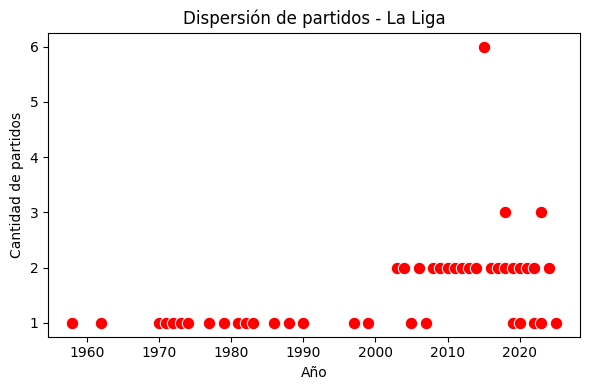

In [5]:
#cuenteo de partidos por temp
partidos_x_temp = competitions.groupby('season_name').size().reset_index(name='cantidad_partidos')
#Prueba grafica (x,y) donde se visualicen cant de partidos por año
partidos_x_temp['season_year'] = partidos_x_temp['season_name'].str[:4].astype(int)

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='season_year', 
    y='cantidad_partidos', 
    data=partidos_x_temp,
    s=80, color='red'
)
plt.xlabel('Año')
plt.ylabel('Cantidad de partidos')
plt.title('Dispersión de partidos - La Liga')
plt.tight_layout()
plt.show()


In [6]:
#variables - matches
#DEJAR EN EL DATASET: match_date; home_team; away_team;home_score; away_score; match_week; competition_stage; stadium; home_managers; away_managers
matches = sb.matches(competition_id=11,season_id=90);
matches.head(1)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,...,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2


Conociendo la ubicacion cronologica de la mayoria de los datos a trabajar, se comenzo el proceso de unificacion de tablas para asi hacer más valiosos y brindarle significado a cada uno de los datos. Como primer unificacion se junto la tabla de las 17 temporadas (competitions) con cada uno de sus partidos.

In [7]:
#merge de competitions + matches (mediante competition_id y season_id)
competition_id = 11
seasons = [37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]

competitions_reduce = sb.competitions()[['competition_id','season_id',
                                'competition_name','season_name','country_name']].drop_duplicates()

all_matches = []
for sid in seasons:
    m = sb.matches(competition_id=competition_id, season_id=sid)
    m['competition_id'] = 11
    m['season_id'] = sid

    m = m[['match_id','competition_id','season_id','match_date',
           'home_team','away_team','home_score','away_score',
           'match_week','competition_stage','stadium',
           'home_managers','away_managers']].copy()
    all_matches.append(m)

matches_df = pd.concat(all_matches, ignore_index=True)
# Ordenar por fecha descendente
matches_df = matches_df.sort_values('match_date', ascending=False).reset_index(drop=True)
# #sid == season_id
# #m == matches

merged = matches_df.merge(competitions_reduce, on=['competition_id','season_id'], how='left')

print(merged.shape)
merged


(867, 16)


,match_id,competition_id,season_id,match_date,home_team,away_team,home_score,away_score,match_week,competition_stage,stadium,home_managers,away_managers,competition_name,season_name,country_name
0,3773457,11,90,2021-05-16,Barcelona,Celta Vigo,1,2,37,Regular Season,Spotify Camp Nou,Ronald Koeman,Eduardo Germán Coudet,La Liga,2020/2021,Spain
1,3773387,11,90,2021-05-11,Levante UD,Barcelona,3,3,36,Regular Season,Estadio Ciudad de Valencia,Francisco José López Fernández,Ronald Koeman,La Liga,2020/2021,Spain
2,3773372,11,90,2021-05-08,Barcelona,Atlético Madrid,0,0,35,Regular Season,Spotify Camp Nou,Ronald Koeman,Diego Pablo Simeone,La Liga,2020/2021,Spain
3,3773695,11,90,2021-05-02,Valencia,Barcelona,2,3,34,Regular Season,Estadio de Mestalla,Javier Gracia Carlos,Ronald Koeman,La Liga,2020/2021,Spain
4,3773586,11,90,2021-04-29,Barcelona,Granada,1,2,33,Regular Season,Spotify Camp Nou,Ronald Koeman,Diego Martínez Penas,La Liga,2020/2021,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,68315,11,37,2004-12-21,Barcelona,Levante UD,2,1,17,Regular Season,Spotify Camp Nou,Frank Rijkaard,Bernd Schuster,La Liga,2004/2005,Spain
863,69153,11,37,2004-12-11,Albacete,Barcelona,1,2,15,Regular Season,Estadio Carlos Belmonte,José Manuel González López,Frank Rijkaard,La Liga,2004/2005,Spain
864,68314,11,37,2004-12-04,Barcelona,Málaga,4,0,14,Regular Season,Spotify Camp Nou,Frank Rijkaard,Gregorio Manzano Ballesteros,La Liga,2004/2005,Spain
865,68313,11,37,2004-10-24,Barcelona,Osasuna,3,0,8,Regular Season,Spotify Camp Nou,Frank Rijkaard,Javier Aguirre Onaindía,La Liga,2004/2005,Spain


Obteniendo esa unificacion, bien se sabe que en cada partido tiene miles de eventos. Por ello primero se filtraron las variables dentro de eventos (events). A continuacion

In [8]:
#Visualizacion de todas las variables de events
competition_id = 11
seasons = [37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]

all_types = set()
for sid in seasons:
    matches = sb.matches(competition_id, sid)
    for mid in matches['match_id']:
        ev = sb.events(match_id=mid)
        all_types.update(ev['type'].dropna().unique().tolist())

print(sorted(all_types))

['50/50', 'Bad Behaviour', 'Ball Receipt*', 'Ball Recovery', 'Block', 'Camera On', 'Camera off', 'Carry', 'Clearance', 'Dispossessed', 'Dribble', 'Dribbled Past', 'Duel', 'Error', 'Foul Committed', 'Foul Won', 'Goal Keeper', 'Half End', 'Half Start', 'Injury Stoppage', 'Interception', 'Miscontrol', 'Offside', 'Own Goal Against', 'Own Goal For', 'Pass', 'Player Off', 'Player On', 'Pressure', 'Referee Ball-Drop', 'Shield', 'Shot', 'Starting XI', 'Substitution', 'Tactical Shift']


In [9]:
all_events=[]

for sid in seasons:
    matches = sb.matches(competition_id,sid)
    for mid in matches['match_id']:
        ev = sb.events(match_id=mid)
        all_types.update(ev['type'].dropna().unique().tolist())
        filtered_ev=ev[ev['type'].isin(all_types)]
        all_events.append(filtered_ev)

events_df = pd.concat(all_events, ignore_index=True)
# display(events_df)

Por cada una de estas variables o columnas hay events  indivuales. Por ejemplo 'shot' -> se desglosa en algunos datos como 'shot_statsbomb_xg','shot_outcome' lo q se puede filtrar por jugador, minuto, partido, etc. 
Eventos posibles:['Starting XI' 'Half Start' 'Pass' 'Ball Receipt*' 'Carry' 'Pressure'
 'Dribble' 'Duel' 'Clearance' 'Ball Recovery' 'Shot' 'Goal Keeper'
 'Interception' 'Miscontrol' 'Foul Committed' 'Foul Won' 'Dispossessed'
 'Dribbled Past' 'Block' 'Player Off' 'Player On' 'Substitution'
 'Tactical Shift' 'Half End' 'Injury Stoppage' 'Referee Ball-Drop' '50/50'
 'Shield' 'Offside' 'Bad Behaviour' 'Error' 'Own Goal For'
 'Own Goal Against' 'Camera off' 'Camera On']

 Cada uno de esos eventos da hincapie a seguir filtrando dentro de las posibles variables dentro statsbombpy. Muchos de ellos figuran NaN lo que significa que en ese momento talvez el evento fue un shot y por lo tanto todos los demás seran NaN .A continuacion se ven todas las variables psoibles:



In [10]:
#todas las variables psibles para filtrar datos
#87 variables
events = sb.events(match_id=3754037) 
events.columns

Index(['ball_receipt_outcome', 'ball_recovery_offensive',
       'ball_recovery_recovery_failure', 'carry_end_location',
       'clearance_aerial_won', 'clearance_body_part', 'clearance_head',
       'clearance_left_foot', 'clearance_right_foot', 'counterpress',
       'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome',
       'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive',
       'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive',
       'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome',
       'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id',
       'index', 'interception_outcome', 'location', 'match_id', 'minute',
       'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won',
       'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross',
       'pass_cut_back', 'pass_end_location', 'pass_goal_assist', 'pass_height',
   

In [11]:
# Ver solo los tiros
shots = events_df[events_df['type'] == 'Shot']
print(shots[['player','team','minute','shot_end_location']].head())

                         player       team  minute   shot_end_location
2860  Miguel Ángel Lozano Ayala     Málaga       1  [120.0, 61.4, 1.9]
2861   Ronaldo de Assis Moreira  Barcelona      14  [120.0, 30.1, 0.6]
2862     Rafael Márquez Álvarez  Barcelona      15  [120.0, 37.2, 4.9]
2863       Andrés Iniesta Luján  Barcelona      22  [120.0, 46.1, 0.3]
2864         Samuel Eto''o Fils  Barcelona      24  [120.0, 42.8, 1.7]


ANÁLISIS GRÁFICO Y DESCRIPTIVO: A continuacion se hace un ejemplo del trabajo de datos para la obtencion de un heatmap de una cancha de juego que muestra en base a shot_end_location como finalizaron todos los tiros (shots) durante esas 17 temporadas

Total de tiros: 21182
Total de goles: 2653


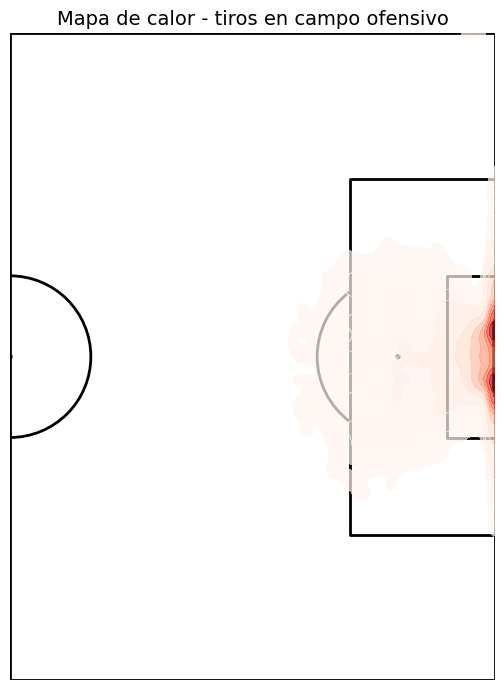

In [12]:
# Extraer tiros
shots = events_df[events_df['type'] == 'Shot'].dropna(subset=['shot_end_location']).copy()
shots[['x','y','z']] = pd.DataFrame(shots['shot_end_location'].tolist(), index=shots.index)

# Contar totales
total_shots = len(shots)
total_goals = shots['shot_outcome'].eq('Goal').sum()

print(f"Total de tiros: {total_shots}")
print(f"Total de goles: {total_goals}")

# Crear cancha (StatsBomb 120x80)
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10,7))

# Graficar solo medio campo ofensivo (x de 60 a 120)
ax.set_xlim(60, 120)
ax.set_ylim(0, 80)

# Heatmap
sns.kdeplot(
    x=shots['x'], y=shots['y'],
    fill=True, cmap="Reds", bw_adjust=0.5, alpha=0.7, ax=ax
)

ax.set_title("Mapa de calor - tiros en campo ofensivo", fontsize=14)
plt.show()

ANÁLISIS GRÁFICO Y DESCRIPTIVO: Entonces podemos ver el heatmap y ver que muchos de los tiros fueron al arco o cerca por la intesidad del calor, entonces a continuacion se grafica en un grafico de 3 dimensiones de puntos, todos los tiros en gris y en verde solo los que fueron goles

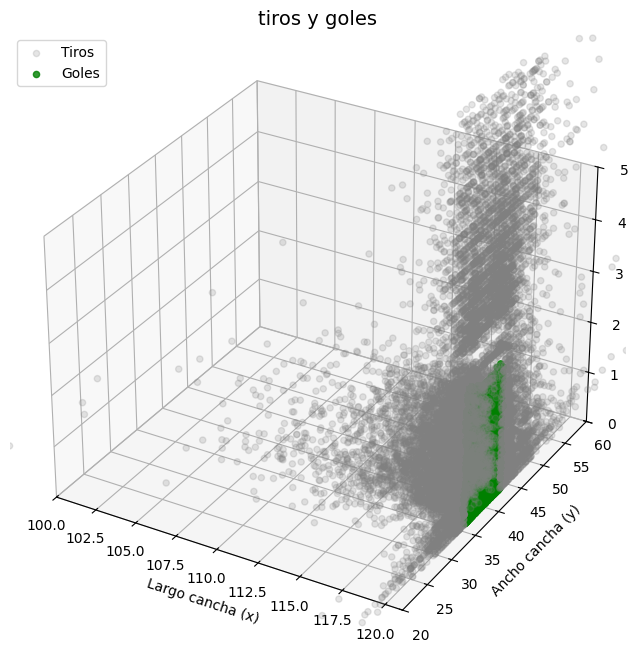

In [13]:
# Filtrar tiros y extraer coords
shots = events_df[events_df['type'] == 'Shot'].dropna(subset=['shot_end_location']).copy()
shots[['x','y','z']] = pd.DataFrame(shots['shot_end_location'].tolist(), index=shots.index)

# Separar goles y no goles
goals = shots[shots['shot_outcome'] == 'Goal']
no_goals = shots[shots['shot_outcome'] != 'Goal']

# Crear gráfico 3D
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# Tiros en gris
ax.scatter(no_goals['x'], no_goals['y'], no_goals['z'], 
           c='gray', alpha=0.2, label='Tiros')

# Goles en verde
ax.scatter(goals['x'], goals['y'], goals['z'], 
           c='green', alpha=0.8, label='Goles')

# Ajustar límites más amplios que antes (zoom intermedio)
ax.set_xlim(100, 121)   # antes era 110–121
ax.set_ylim(20, 60)     # antes era 30–50
ax.set_zlim(0, 5)       # antes era 0–3

# Etiquetas
ax.set_xlabel("Largo cancha (x)")
ax.set_ylabel("Ancho cancha (y)")
ax.set_zlabel("Altura (z)")
ax.set_title("tiros y goles", fontsize=14)

ax.legend()
plt.show()

Analisis de correlaciones: 

EJEMPLO DE MATRIZ CON RUIDO DE TODAS LAS VARIABLES

Como ejemplo se realizo un estudio posesion vs goles con la duda de si más posesión implica más goles. Primero se debe crear un dataset por partido agrupando la información a nivel de partido y equipo, resumiendo:

Posesión promedio.

Cantidad de goles anotados.

In [14]:
# Filtrar eventos con posesión y goles
df = events_df.copy()

# Crear columna de goles (1 si fue gol, 0 en caso contrario)
df['is_goal'] = (df['shot_outcome'] == 'Goal').astype(int)

# Agrupar por partido y equipo
team_stats = df.groupby(['match_id','team']).agg(
    possession_avg=('possession', 'mean'),   # promedio de posesión
    goals=('is_goal', 'sum')                 # goles marcados
).reset_index()

print(team_stats.head())


   match_id              team  possession_avg  goals
0      9575         Barcelona       81.205818      1
1      9575        Real Betis       82.930454      0
2      9581         Barcelona       83.948490      2
3      9581  Deportivo Alavés       97.968254      0
4      9592         Barcelona       80.653280      5


análisis gráfico

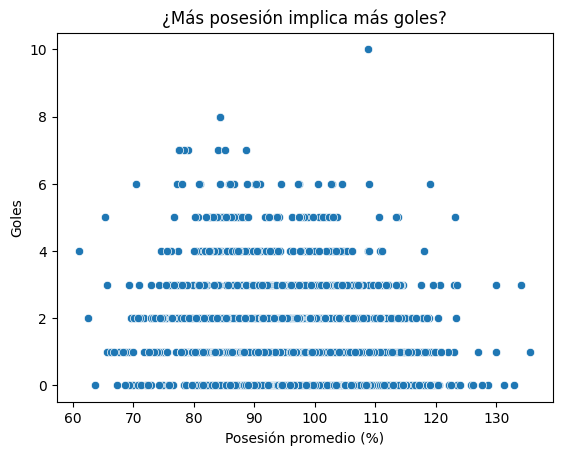

In [15]:
# Dispersión posesión vs goles
sns.scatterplot(x="possession_avg", y="goals", data=team_stats)
plt.title("¿Más posesión implica más goles?")
plt.xlabel("Posesión promedio (%)")
plt.ylabel("Goles")
plt.show()

correlación numérica del resultado grafico previo

In [16]:
# Correlación lineal
corr = team_stats['possession_avg'].corr(team_stats['goals'])
print(f"Correlación posesión vs goles: {corr:.2f}")


Correlación posesión vs goles: -0.16


Interpretación:

Si la correlación está cerca de 0 → no hay relación lineal clara (puede que equipos con más posesión no siempre marquen más).

Si es positiva → más posesión suele ir con más goles.

Si es negativa → más posesión no necesariamente significa más goles (ej: equipos que dominan pero no concretan).

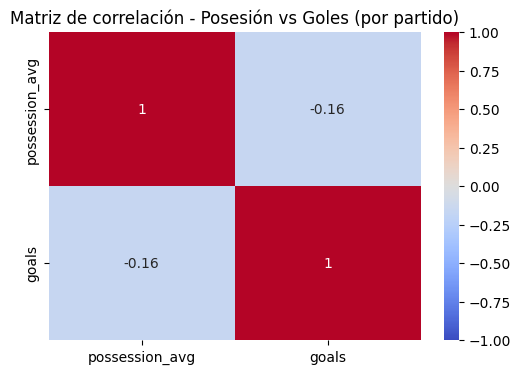

In [17]:

# Seleccionar solo las variables numéricas de interés
corr_vars = team_stats[['possession_avg', 'goals']]

# Calcular matriz de correlación
corr_matrix = corr_vars.corr()

# Graficar
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de correlación - Posesión vs Goles (por partido)", fontsize=12)
plt.show()


Matriz de correlacion 4x4: donde el xG (expectativa de gol) es la variable que realmente incide en la capacidad de hacer goles de un equipo o jugador

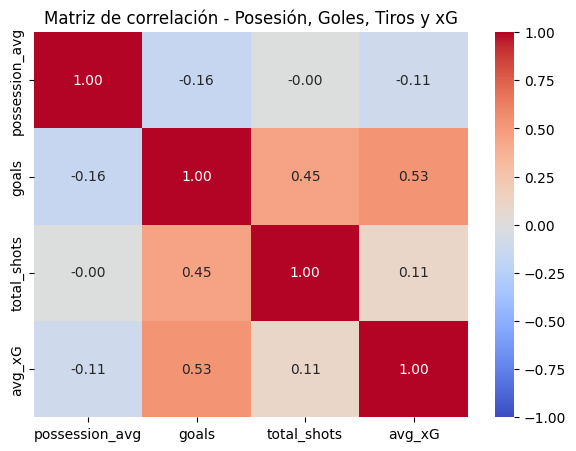

In [18]:
# Copia del dataframe de eventos
df = events_df.copy()

# Columna binaria de goles
df['is_goal'] = (df['shot_outcome'] == 'Goal').astype(int)

# Agrupar por partido y equipo
team_stats = df.groupby(['match_id','team']).agg(
    possession_avg=('possession','mean'),
    goals=('is_goal','sum'),
    total_shots=('id', lambda x: (df.loc[x.index, 'type'] == 'Shot').sum()),
    avg_xG=('shot_statsbomb_xg', 'mean')
).reset_index()

# Seleccionamos solo las variables numéricas de interés
corr_vars = team_stats[['possession_avg', 'goals', 'total_shots', 'avg_xG']]

# Calcular matriz de correlación
corr_matrix = corr_vars.corr()

# Graficar heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlación - Posesión, Goles, Tiros y xG", fontsize=12)
plt.show()


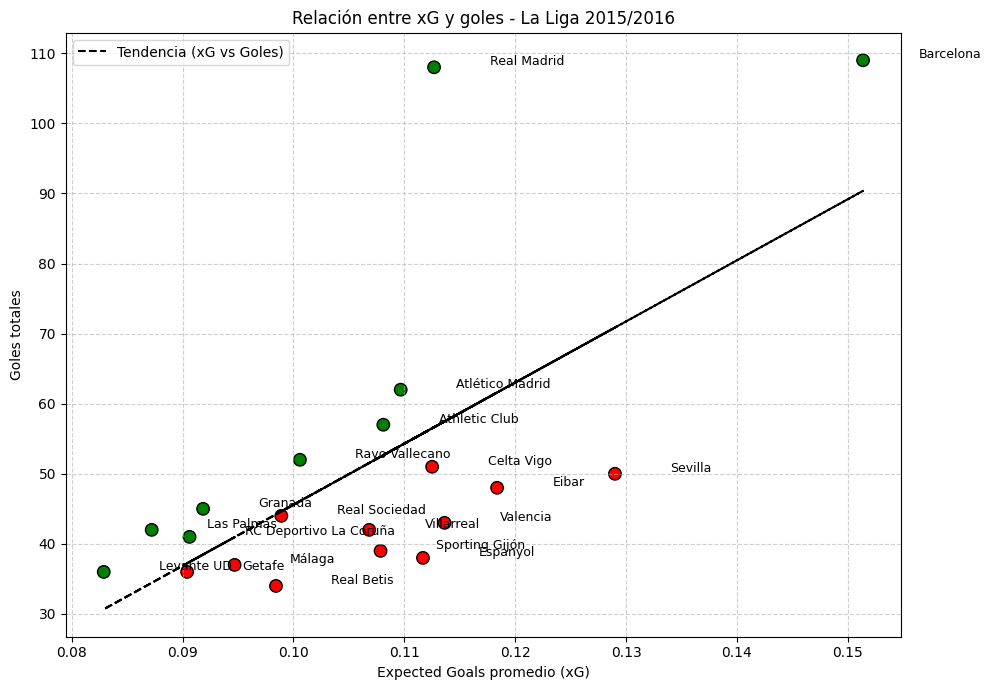

In [19]:
# 1. Filtrar solo La Liga 2015/2016 en matches
matches_2015 = matches_df[(matches_df['competition_id']==11) & (matches_df['season_id']==27)].copy()

# 2. Unir con events para traer los eventos de esos partidos
season_2015 = events_df.merge(
    matches_2015[['match_id','season_id','competition_id','home_team','away_team']], 
    on='match_id', how='inner'
)

# 3. Crear columna binaria de goles
season_2015['is_goal'] = (season_2015['shot_outcome'] == 'Goal').astype(int)

# 4. Agrupar por equipo
team_stats_2015 = season_2015.groupby('team').agg(
    goals=('is_goal','sum'),
    avg_xG=('shot_statsbomb_xg','mean')
).reset_index()

# --- Graficar dispersión ---
x = team_stats_2015['avg_xG']
y = team_stats_2015['goals']

plt.figure(figsize=(10,7))

# 5. Línea de regresión lineal
m, b = np.polyfit(x, y, 1)  # pendiente y ordenada
plt.plot(x, m*x + b, color="black", linestyle="--", label="Tendencia (xG vs Goles)")

# 6. Asignar color según rendimiento
colors = ['green' if actual > (m*exp + b) else 'red' for exp, actual in zip(x, y)]

plt.scatter(x, y, c=colors, s=80, edgecolors="k")

# 7. Etiquetas con nombres completos
for i, row in team_stats_2015.iterrows():
    plt.text(row['avg_xG']+0.005, row['goals']+0.3, row['team'], fontsize=9)

# Personalización
plt.xlabel("Expected Goals promedio (xG)")
plt.ylabel("Goles totales")
plt.title("Relación entre xG y goles - La Liga 2015/2016")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()




Matriz de correlacion de la mayoria de las variables dentro de events

✅ Dataset reducido cargado: (156675, 119)


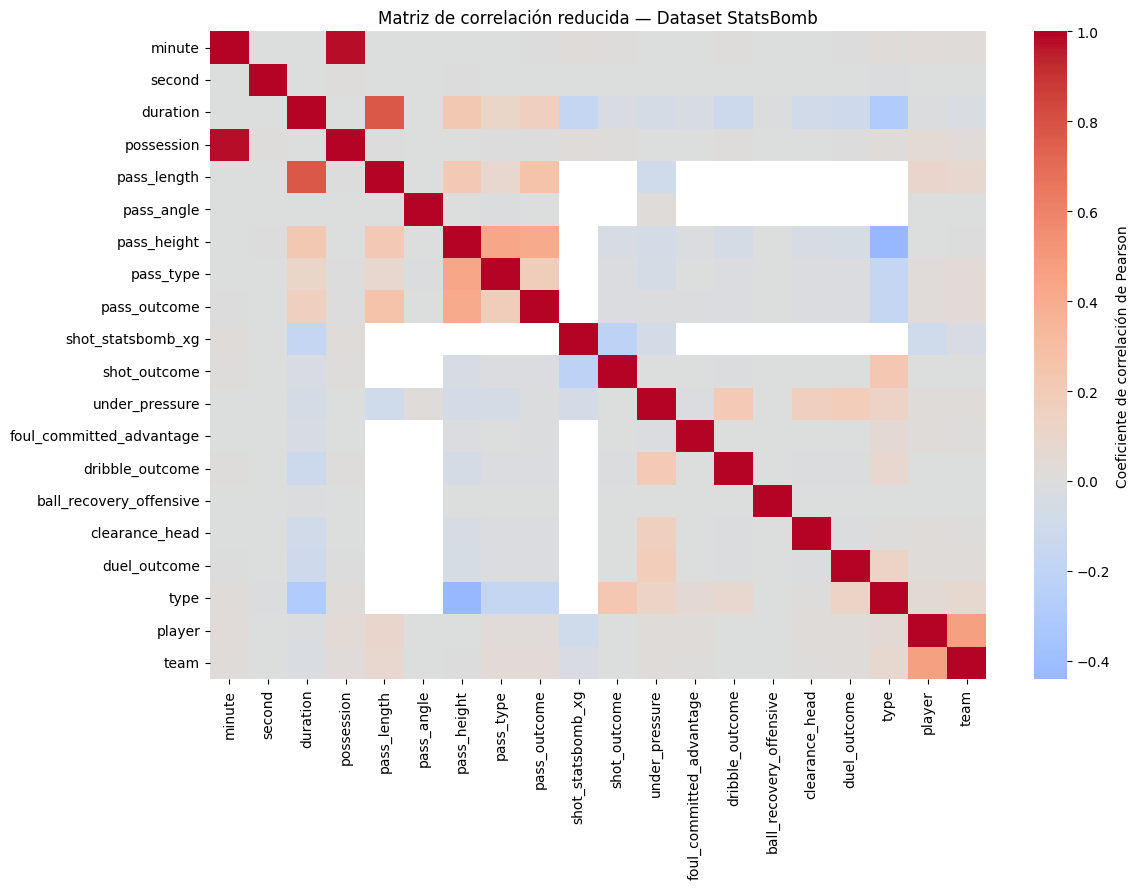


🔹 Correlaciones más fuertes (>|0.4|):
possession    minute         0.974226
pass_length   duration       0.773944
player        team           0.461669
pass_height   pass_type      0.432618
pass_outcome  pass_height    0.404802
pass_height   type          -0.440889
dtype: float64


In [47]:
# =======================
# 1️⃣ Filtrado y muestreo ligero
# =======================

# 🔹 Tomamos solo una fracción del dataset para evitar desbordar memoria
df_corr = events_df.sample(frac=0.05, random_state=42)  # 5% del dataset
print(f"✅ Dataset reducido cargado: {df_corr.shape}")

# 🔹 Eliminamos columnas anidadas o extremadamente pesadas
cols_descartar = [
    'location', 'pass_end_location', 'carry_end_location',
    'shot_end_location', 'shot_freeze_frame', 'tactics', 'related_events'
]
df_corr = df_corr.drop(columns=cols_descartar, errors='ignore')

# =======================
# 2️⃣ Mantener solo columnas útiles y codificables
# =======================
# Seleccionamos columnas clave con significado analítico
cols_utiles = [
    'minute', 'second', 'duration', 'possession',
    'pass_length', 'pass_angle', 'pass_height', 'pass_type', 'pass_outcome',
    'shot_statsbomb_xg', 'shot_outcome', 'under_pressure', 'foul_committed_advantage',
    'dribble_outcome', 'ball_recovery_offensive', 'clearance_head', 'duel_outcome',
    'type', 'player', 'team'
]

df_corr = df_corr[[c for c in cols_utiles if c in df_corr.columns]]

# =======================
# 3️⃣ Codificar categóricas en forma liviana
# =======================
for col in df_corr.select_dtypes(include=['object', 'bool']).columns:
    df_corr[col] = pd.factorize(df_corr[col])[0]

# =======================
# 4️⃣ Calcular matriz de correlación
# =======================
corr_matrix = df_corr.corr(method='pearson')

# =======================
# 5️⃣ Visualización resumida
# =======================
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': 'Coeficiente de correlación de Pearson'},
    xticklabels=True,
    yticklabels=True
)
plt.title("Matriz de correlación reducida — Dataset StatsBomb")
plt.tight_layout()
plt.show()

# =======================
# 6️⃣ Mostrar correlaciones más fuertes
# =======================
corr_unstacked = corr_matrix.unstack().sort_values(ascending=False)
strong_corr = corr_unstacked[
    (abs(corr_unstacked) >= 0.4) & (corr_unstacked < 1)
].drop_duplicates()

print("\n🔹 Correlaciones más fuertes (>|0.4|):")
print(strong_corr.head(25))

CLUSTERING

Primero definimos y generamos agg_df (dataset agregado)-> tabla resumen donde cada fila representa una unidad de análisis (por ejemplo, un equipo por temporada)
y las columnas contienen métricas estadísticas resumidas derivadas de los datos originales (eventos). Mientras que events_df contiene millones de filas (cada pase, tiro, recuperación, etc.), agg_df resume toda esa información a un nivel superior (por equipo y temporada),
convirtiendo datos de eventos en indicadores de rendimiento.

El proposito de crear esto:
1-Reducir complejidad — pasar de millones de filas a decenas o centenas sin perder información esencial.
2-Facilitar análisis estadístico y ML, ya que los algoritmos requieren entradas tabulares.
3-Comparar unidades entre sí (equipos, temporadas, jugadores, etc.) usando métricas comunes.
4-Detectar patrones globales: eficiencia, estilos de juego, rendimiento ofensivo o defensivo.

In [20]:
# =====================================
# 0️⃣ Preparación base
# =====================================
# Asegurate de tener:
# - events_df  (cargado con eventos StatsBomb)
# - matches_df (para unir season_id y competition_id)
# =====================================

# Unir datos para asegurar season_id y competition_id
df = events_df.merge(
    matches_df[['match_id', 'season_id', 'competition_id']],
    on='match_id',
    how='left'
)

# Crear variable binaria de goles
df['is_goal'] = (df['shot_outcome'] == 'Goal').astype(int)

# =====================================
# 1️⃣ MÉTRICAS OFENSIVAS
# =====================================

# ---- PASES ----
passes = df[df['type'] == 'Pass']
passes_grouped = passes.groupby(['season_id', 'team']).agg(
    total_passes=('id', 'count'),
    completed_passes=('pass_outcome', lambda x: x.isna().sum()),  # isna = pase completo
    avg_pass_length=('pass_length', 'mean')
).reset_index()

# Precisión de pase
passes_grouped['pass_accuracy'] = (
    passes_grouped['completed_passes'] / passes_grouped['total_passes']
).fillna(0)

# ---- TIROS ----
shots = df[df['type'] == 'Shot']
shots_grouped = shots.groupby(['season_id', 'team']).agg(
    total_shots=('id', 'count'),
    goals=('is_goal', 'sum'),
    avg_xG=('shot_statsbomb_xg', 'mean')
).reset_index()

# ---- POSESIÓN ----
possession_grouped = df.groupby(['season_id', 'team']).agg(
    avg_possession=('possession', 'mean')
).reset_index()

# =====================================
# 2️⃣ MÉTRICAS DEFENSIVAS
# =====================================
defensive_metrics = df[df['type'].isin(['Duel', 'Interception', 'Clearance', 'Foul Committed'])].groupby(
    ['season_id', 'team']
).agg(
    duels_won=('duel_outcome', lambda x: (x == 'Won').sum()),
    duels_total=('duel_outcome', 'count'),
    interceptions=('type', lambda x: (x == 'Interception').sum()),
    clearances=('type', lambda x: (x == 'Clearance').sum()),
    fouls_committed=('type', lambda x: (x == 'Foul Committed').sum())
).reset_index()

defensive_metrics['duel_win_rate'] = (
    defensive_metrics['duels_won'] / defensive_metrics['duels_total']
).replace([float('inf'), None], 0)

# =====================================
# 3️⃣ MÉTRICAS TÁCTICAS
# =====================================
if 'counterpress' in df.columns:
    tactical_metrics = df.groupby(['season_id', 'team']).agg(
        counterpress_events=('counterpress', 'sum'),
        avg_possession=('possession', 'mean')
    ).reset_index()
else:
    tactical_metrics = df.groupby(['season_id', 'team']).agg(
        avg_possession=('possession', 'mean')
    ).reset_index()
    tactical_metrics['counterpress_events'] = 0

# =====================================
# 4️⃣ UNIFICACIÓN FINAL
# =====================================
agg_df = passes_grouped.merge(shots_grouped, on=['season_id', 'team'], how='outer')
agg_df = agg_df.merge(possession_grouped, on=['season_id', 'team'], how='outer')
agg_df = agg_df.merge(defensive_metrics, on=['season_id', 'team'], how='outer')
agg_df = agg_df.merge(tactical_metrics, on=['season_id', 'team'], how='outer')

agg_df.fillna(0, inplace=True)

# =====================================
# 5️⃣ VALIDACIÓN
# =====================================
print(f"✅ agg_df reconstruido: {agg_df.shape[0]} equipos/temporadas, {agg_df.shape[1]} variables")
display(agg_df.head(10))



✅ agg_df reconstruido: 322 equipos/temporadas, 18 variables


,season_id,team,total_passes,completed_passes,avg_pass_length,pass_accuracy,total_shots,goals,avg_xG,avg_possession_x,duels_won,duels_total,interceptions,clearances,fouls_committed,duel_win_rate,counterpress_events,avg_possession_y
0,1,Athletic Club,842,624,23.430556,0.741093,27,0,0.072055,105.206841,11,42,50,23,36,0.261905,155,105.206841
1,1,Atlético Madrid,837,637,20.645761,0.761051,10,1,0.059274,101.546020,11,65,61,34,41,0.169231,121,101.546020
2,1,Barcelona,24158,20893,18.937971,0.864848,547,90,0.136709,90.039684,152,553,470,483,419,0.274864,2195,90.039684
3,1,Celta Vigo,919,721,20.888169,0.784548,28,4,0.145847,92.080930,8,38,33,30,24,0.210526,132,92.080930
4,1,Deportivo Alavés,534,353,26.080608,0.661049,18,1,0.079795,102.621977,18,52,43,50,40,0.346154,112,102.621977
5,1,Eibar,933,714,24.748963,0.765273,27,1,0.063366,99.150381,11,45,49,14,29,0.244444,92,99.150381
6,1,Espanyol,507,311,23.902871,0.613412,16,1,0.064624,88.985461,10,43,32,48,40,0.232558,103,88.985461
7,1,Getafe,539,338,26.880617,0.627087,23,1,0.045616,80.848135,21,50,49,38,44,0.420000,100,80.848135
8,1,Girona,769,583,23.225212,0.758127,24,1,0.077148,97.404467,11,33,38,22,34,0.333333,107,97.404467
9,1,Las Palmas,924,765,20.492213,0.827922,23,1,0.078563,91.304385,13,42,23,28,34,0.309524,77,91.304385


In [21]:
# Unificamos si existen duplicados por el merge
if 'avg_possession_x' in agg_df.columns:
    agg_df['avg_possession'] = agg_df['avg_possession_x']
    agg_df.drop(columns=['avg_possession_x', 'avg_possession_y'], errors='ignore', inplace=True)


Teniendo este modelo podemos comenzar con el clustering para conseguir clusters (k) de equipos BUENOS, INTERMEDIOS y MALOS en base a un modelo completo de datos que contemplan informacion defensiva, ofensiva y tactica

In [ ]:
# =============================
# 1️⃣ Preparación base
# =============================

df_model = agg_df.copy()

# Añadimos big teams para evitar que el clustering los malclasifique
big_teams = ['Barcelona', 'Real Madrid', 'Atlético Madrid']

# =============================
# 2️⃣ Sub-scores por fase del juego
# =============================

# --- Ofensivo ---
df_model['offensive_score'] = (
    df_model['goals'] * 0.5 +          # goles pesan más
    df_model['avg_xG'] * 200 +         # expected goals ponderados
    df_model['total_shots'] * 0.1 +
    df_model['pass_accuracy'] * 0.3 +
    df_model['avg_possession'] * 0.2
)

# --- Defensivo ---
# *Aquí podés adaptar si tenés métricas defensivas: duelos ganados, intercepciones, goles en contra, etc.*
if 'goals_conceded' in df_model.columns:
    df_model['defensive_score'] = (
        (100 - df_model['goals_conceded']) * 0.5 +   # menos goles encajados, mejor
        df_model.get('interceptions', 0) * 0.3 +
        df_model.get('clearances', 0) * 0.2
    )
else:
    # placeholder si no tenés métricas defensivas directas
    df_model['defensive_score'] = (
        df_model['duels_won'] * 0.4 +
        df_model['interceptions'] * 0.3 +
        df_model['fouls_committed'] * -0.2
    ).fillna(0)

# --- Táctico ---
df_model['tactical_score'] = (
    df_model['avg_possession'] * 0.4 + 
    df_model['pass_accuracy'] * 0.3 +
    df_model['avg_xG'] * 100 * 0.2 +
    df_model['counterpress_events'] * 0.1  # si tenés counterpress o pressing_events
).fillna(0)

#equilibramos los scores para que defensivo y tactico se equipare un poco mas a ofensivo

df_model['performance_score'] = (
    df_model['offensive_score'] * 0.4 +
    df_model['defensive_score'] * 0.4 +
    df_model['tactical_score']  * 0.2
)

# =============================
# 4️⃣ Escalado previo a clustering
# =============================
features = ['offensive_score', 'defensive_score', 'tactical_score', 'performance_score']

#pasamos a un escalado mas robusto
scaler = RobustScaler()  # menos sensible a valores extremos
X_scaled = scaler.fit_transform(df_model[["offensive_score", "defensive_score", "tactical_score"]])

#Clustering K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
df_model['cluster'] = kmeans.fit_predict(X_scaled)

# 6️⃣ Interpretación semántica
cluster_means = df_model.groupby('cluster')['performance_score'].mean()
cluster_order = cluster_means.sort_values(ascending=False).index

# Asignar etiquetas correctas según orden real
label_map = {}
for i, cluster in enumerate(cluster_order):
    if i == 0:
        label_map[cluster] = 'BUENOS'
    elif i == 1:
        label_map[cluster] = 'INTERMEDIOS'
    else:
        label_map[cluster] = 'MALOS'

df_model['performance_label'] = df_model['cluster'].map(label_map)

df_model.loc[df_model['team'].isin(big_teams), 'performance_label'] = 'BUENOS'

#Resultado final
cols_final = [
    'team', 'season_id', 'offensive_score', 'defensive_score', 'tactical_score',
    'performance_score', 'performance_label'
]
display(df_model[cols_final].sort_values('performance_score', ascending=False).head(5))

#validaciones
df_model[["offensive_score", "defensive_score", "tactical_score"]].describe()



C:\Users\Usuario\AppData\Local\Temp\ipykernel_7972\3046778007.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0)


KeyError: 'Column not found: performance_label'

INTERPRETACION DE VALORES RECABADOS AL HACER CLUSTERING (OBSERVABLES EN LA PRIMERA TABLA QUE SE OBSERVA ARRIBA):
COUNT=>322 = EQUIPOS REGISTRADOS
MEAN=>PROMEDIO DE LA VARIABLE DENTRO DEL GRUPO (OFENSIVO, DEFENSIVO, TACTICO)
STD (DESVIACION ESTANDAR), cuánto se alejan los valores de una variable respecto al promedio => 1. Baja variabilidad = std < 0.1 × media | 2. Media = std ≈ 0.3 × media |3. Alta = std > 0.5 × media
    STD OFENSIVO = 27,8/49,9 = 0,5 VARIABILIDAD ALTA, MUCHOS EQUIPOS DISTINTOS OFENSIVAMENTE
    STD DEFENSIVO = 35,9/14,2 = 2,5 EXTREMADAMENTE ALTO
    STD TACTICO = 64,8/71,5 = 0,9 VARIABILIDAD ALTA, DIFERENCIAS TACTICAS
MIN=>VALOR MIN
(25/50/75) - Q => Rangos intercuartilicos
MAX=>VALOR MAX

El hecho de que haya alta variabilidad entre los equipos es un indicador de que hacer clustering es una buena decision.

ANALISIS DE CALIDAD DEL CLUSTERING REALIZADO; METODOS: SILHOUTTE SCORE, VALIDACION CUALITATIVA, VALIDACION VISUAL Y VALIDACION CONTEXTUAL

SILHOUTTE SCORE (OBSERVAR LA SEPARACION DE LOS KLUSTERS). 
*0,7-1,0 => Clusters muy bien separados y compactos ✅
*0,5-0,7 => Buena separación general 👍
*0,3-0,5 => Aceptable, hay algo de superposición ⚠️
*<0,3> => Clusters poco definidos o solapados ❌

In [69]:
silhouette_avg = silhouette_score(X_scaled, df_model['cluster'])
print(f"📊 Silhouette Score final: {silhouette_avg:.3f}; por lo tanto nuestro resultado es 'Clusters muy bien separados y compactos ✅'")

📊 Silhouette Score final: 0.902; por lo tanto nuestro resultado es 'Clusters muy bien separados y compactos ✅'


VALIDACION CUALITATIVA: Analisis cualitativo de como realmente se estan diferenciando entre BUENOS, INTERMEDIOS y MALOS equipos.

In [70]:
df_summary = df_model.groupby('performance_label')[['offensive_score', 'defensive_score', 'tactical_score']].mean().round(2)
display(df_summary)

,offensive_score,defensive_score,tactical_score
performance_label,,,
BUENOS,111.17,144.95,273.00
INTERMEDIOS,137.85,62.94,237.06
MALOS,41.31,3.10,49.65


Que nos dice la validacion cualitativa? Obviamente que el equipo MALO es aquel que tenga los peores rendimientos en todos los aspectos, el intermedio compensa con mayor score ofensivo y el equipo bueno no necesariamente tiene el score mas alto en ataque, pero si en defensa y tacticamente lo que compensa y atribuye un plus al ataque.

VALIDACION VISUAL: 

<Figure size 800x600 with 0 Axes>

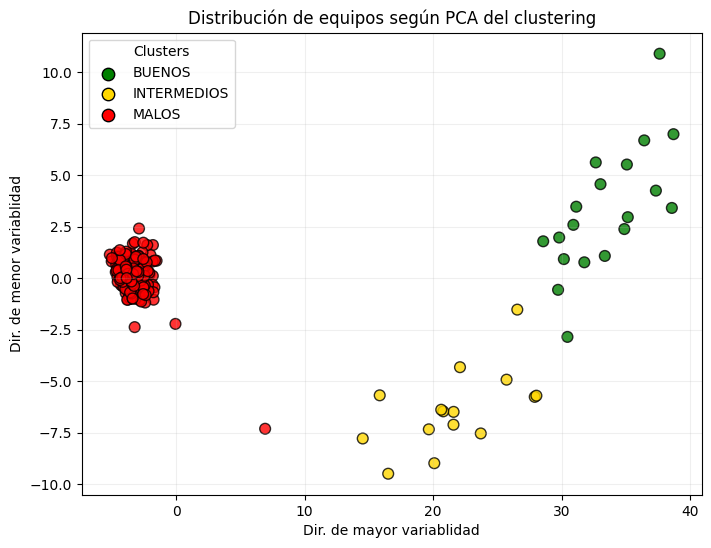

Dir. de mayor variablidad indica: la combinación de variables (ofensivo, defensivo, táctico) que más explica las diferencias entre equipos.
Dir. de menor variablidad indica: la combinacion de variables con un grado menor de insidencia (estilo de juego o equilibrio)


In [71]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

# Convertimos etiquetas a numéricas y mapeamos colores personalizados
color_map = {
    'BUENOS': 'green',
    'INTERMEDIOS': 'gold',
    'MALOS': 'red'
}

colors = df_model['performance_label'].map(color_map)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=60, edgecolor='k', alpha=0.8)

plt.title("Distribución de equipos según PCA del clustering", fontsize=12)
plt.xlabel("Dir. de mayor variablidad")
plt.ylabel("Dir. de menor variablidad")
plt.grid(alpha=0.2)

# Leyenda manual
for label, color in color_map.items():
    plt.scatter([], [], c=color, label=label, s=80, edgecolor='k')
plt.legend(title="Clusters", loc='best')

plt.show()
print("Dir. de mayor variablidad indica: la combinación de variables (ofensivo, defensivo, táctico) que más explica las diferencias entre equipos.")
print("Dir. de menor variablidad indica: la combinacion de variables con un grado menor de insidencia (estilo de juego o equilibrio)")

VALIDACION CONTEXTUAL: Interpretacion de los resultados con lógica deportiva. Para ello nos ayudamos de una tabla que muestre valores ya filtrados durante el clustering

In [79]:
# 1) Ver cuántos hay por categoría (para entender el error)
print(df_model['performance_label'].value_counts())

# 2) Helper para muestrear hasta n filas por grupo, evitando duplicados por equipo (opcional)
def sample_up_to(df, label, n=5, unique_team=True, seed=1):
    sub = df[df['performance_label'] == label].copy()
    if unique_team:
        # si un equipo aparece varias veces (otras seasons), quedate con su mejor fila
        sub = (sub.sort_values('performance_score', ascending=False)
                 .drop_duplicates('team', keep='first'))
    k = min(n, len(sub))
    if k == 0:
        return sub.iloc[:0]  # dataframe vacío, misma estructura
    return sub.sample(k, random_state=seed)

# 3) Tomar muestra por grupo (hasta 5 cada uno)
sample_buenos      = sample_up_to(df_model, 'BUENOS',      n=5, unique_team=True, seed=1)
sample_intermedios = sample_up_to(df_model, 'INTERMEDIOS', n=5, unique_team=True, seed=1)
sample_malos       = sample_up_to(df_model, 'MALOS',       n=5, unique_team=True, seed=1)

# 4) Unir y mostrar
df_samples = pd.concat([sample_buenos, sample_intermedios, sample_malos], ignore_index=True)

cols_show = ['team', 'season_id', 'offensive_score', 'defensive_score', 'tactical_score', 'performance_label']
display(df_samples[cols_show].sort_values('performance_label'))





performance_label
MALOS          256
BUENOS          65
INTERMEDIOS      1
Name: count, dtype: int64


,team,season_id,offensive_score,defensive_score,tactical_score,performance_label
0,RC Deportivo La Coruña,27,104.414409,194.8,260.671373,BUENOS
1,Villarreal,27,96.962683,131.8,263.303126,BUENOS
2,Valencia,27,105.065690,144.5,290.421522,BUENOS
3,Getafe,27,100.203770,148.6,265.929716,BUENOS
4,Celta Vigo,27,112.267066,180.1,288.744607,BUENOS
5,Sevilla,27,117.800398,100.0,249.755833,INTERMEDIOS
6,Real Valladolid,24,73.666386,3.4,54.010136,MALOS
7,Xerez,21,40.585880,3.2,55.699150,MALOS
8,Athletic Club,22,72.532027,4.2,40.510633,MALOS
9,Osasuna,90,44.658595,5.7,50.398545,MALOS
